Successfully loaded dataset with 187 rows and 15 columns.



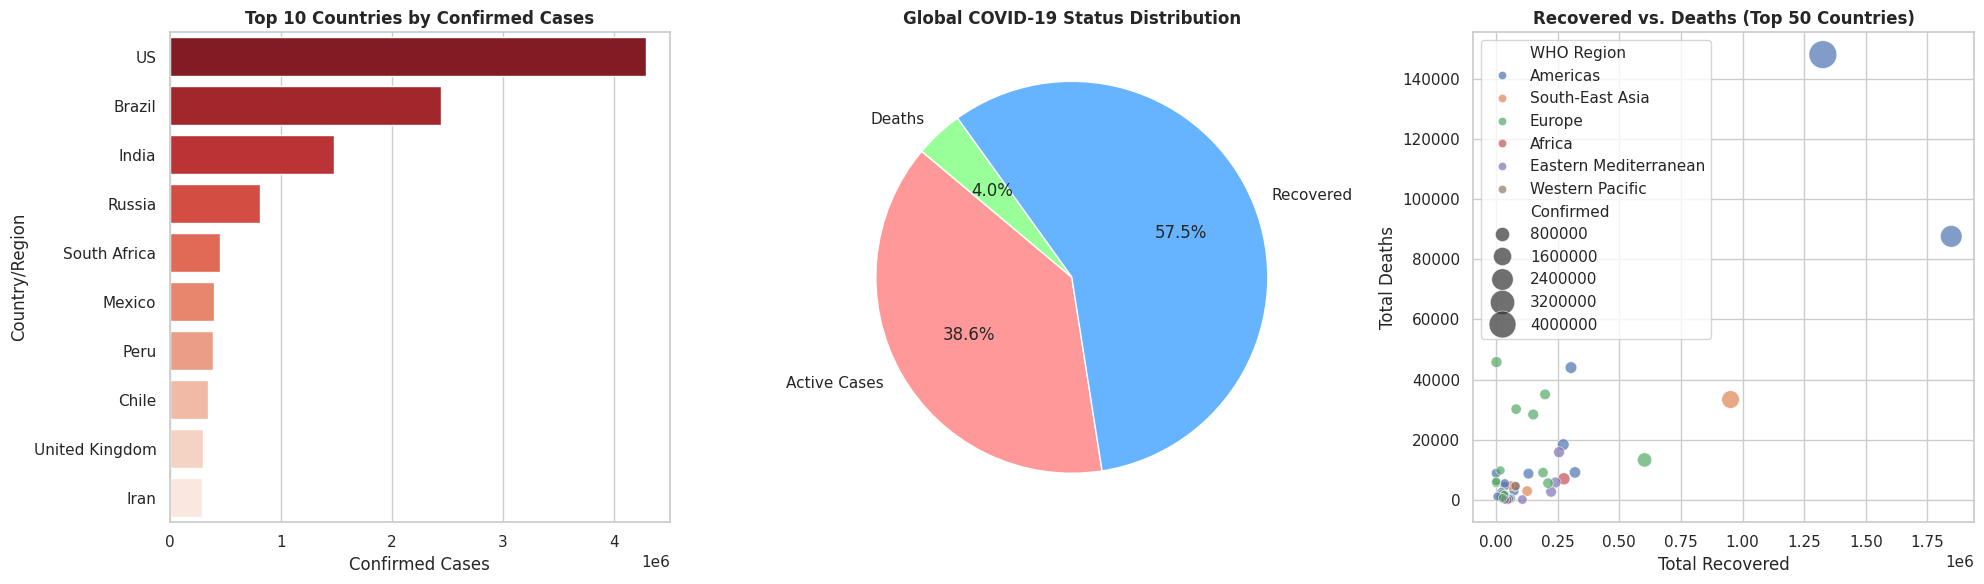

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Load dataset
file_path = "/content/country_wise_latest (1).csv"

try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.\n")
except FileNotFoundError:
    print(f"Error: File not found at '{file_path}'. Please ensure the CSV file is uploaded.")

# 2. Data Cleaning & Preprocessing
# Fill any empty values in WHO Region if present
if "WHO Region" in df.columns:
    df["WHO Region"] = df["WHO Region"].fillna("Unknown")

# 3. Calculate Global Totals
global_confirmed = df["Confirmed"].sum()
global_deaths = df["Deaths"].sum()
global_recovered = df["Recovered"].sum()
global_active = df["Active"].sum()

# Get Top 10 countries by Confirmed cases for visualization
top10_confirmed = df.nlargest(10, "Confirmed")

# 4. Data Visualizations (3 Plots)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Top 10 Countries with Most Confirmed Cases
sns.barplot(
    ax=axes[0],
    data=top10_confirmed,
    x="Confirmed",
    y="Country/Region",
    palette="Reds_r",
    hue="Country/Region",
    legend=False
)
axes[0].set_title("Top 10 Countries by Confirmed Cases", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Confirmed Cases")
axes[0].set_ylabel("Country/Region")

# Plot 2: Pie Chart (Global Case Breakdown)
case_breakdown = [global_active, global_recovered, global_deaths]
case_labels = ["Active Cases", "Recovered", "Deaths"]
colors = ["#ff9999", "#66b3ff", "#99ff99"]

axes[1].pie(
    case_breakdown,
    labels=case_labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors
)
axes[1].set_title("Global COVID-19 Status Distribution", fontsize=12, fontweight="bold")

# Plot 3: Scatter Plot of Recovered vs. Deaths (Top 50 Countries)
top50_countries = df.nlargest(50, "Confirmed")
sns.scatterplot(
    ax=axes[2],
    data=top50_countries,
    x="Recovered",
    y="Deaths",
    hue="WHO Region",
    size="Confirmed",
    sizes=(40, 400),
    alpha=0.7
)
axes[2].set_title("Recovered vs. Deaths (Top 50 Countries)", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Total Recovered")
axes[2].set_ylabel("Total Deaths")

plt.tight_layout()
plt.show()

# 5. Interactive Dashboard (Plotly Map of Confirmed Cases)
fig_dashboard = px.scatter_geo(
    df,
    locations="Country/Region",
    locationmode="country names",
    color="WHO Region",
    hover_name="Country/Region",
    size="Confirmed",
    projection="natural earth",
    title="Global COVID-19 Confirmed Cases Map"
)
fig_dashboard.show()